# Huấn luyện model NER tiếng Việt, từ dữ liệu thô tới artifact phục vụ được

Notebook này lo **ba giai đoạn đầu** của vòng đời một sản phẩm NLP. Chạy hết notebook là có đủ
artifact để `docker compose up -d` ở thư mục gốc dựng được một hệ thống phục vụ thật.

| Mục | Nội dung | Giai đoạn trong vòng đời |
|---|---|---|
| 1-2 | Nạp dữ liệu, khảo sát, hiểu bài toán | Dữ liệu |
| 3-5 | Tokenize, huấn luyện, đánh giá | Huấn luyện |
| 6-8 | Phân tích lỗi, thử tình huống thật, bài học về tiền xử lý | Đánh giá |
| 9-10 | Xuất ONNX, ghi vào kho model của Triton | Đóng gói |

**Bài toán.** Nhận diện thực thể có tên (NER) cho tiếng Việt: tìm và phân loại thực thể trong câu
thành `PER` (người), `ORG` (tổ chức), `LOC` (địa điểm), gán nhãn theo chuẩn BIO.

**Chạy ở đâu cũng được.** Notebook tự nhận biết môi trường:

- **Google Colab**: chọn Runtime > Change runtime type > GPU (T4 là đủ). Artifact sẽ được đóng gói
  thành một file `.zip` để tải về, sau đó giải nén vào repo trên máy của bạn.
- **Máy cá nhân có GPU**: notebook tự tìm thư mục gốc repo và ghi artifact vào đúng chỗ.
- **Không có GPU**: vẫn chạy được, chỉ chậm hơn. Giảm `num_train_epochs` xuống 1 để thử nhanh.

In [1]:
# Cài các gói còn thiếu. Trên Colab thì torch và transformers đã có sẵn nên bước
# này chỉ mất vài chục giây; trên máy cá nhân lần đầu sẽ lâu hơn.
import importlib.util, subprocess, sys


def ensure(pkg, import_name=None):
    """Chỉ cài khi thực sự thiếu. Cài đè gói đã có là cách dễ nhất để làm hỏng
    một môi trường đang chạy tốt."""
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        print(f"Đang cài {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)


for pkg, imp in [
    ("transformers", "transformers"),
    ("datasets", "datasets"),
    ("seqeval", "seqeval"),
    ("onnx", "onnx"),
    ("onnxruntime", "onnxruntime"),
    ("accelerate", "accelerate"),
]:
    ensure(pkg, imp)

import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)          # cố định hạt giống để chạy lại ra cùng kết quả

print(f"Thiết bị: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))
if DEVICE == "cpu":
    print("Không thấy GPU. Notebook vẫn chạy được nhưng huấn luyện sẽ lâu hơn nhiều.")
    print("Trên Colab: Runtime > Change runtime type > Hardware accelerator > GPU.")

Thiết bị: cuda (NVIDIA GeForce RTX 3090)


In [2]:
from pathlib import Path

# Xác định nơi ghi artifact. Đường dẫn tương đối trong notebook tính theo THƯ MỤC
# ĐANG CHẠY KERNEL, không theo vị trí file .ipynb, nên chạy từ chỗ khác là ghi ra
# chỗ khác mà không báo lỗi gì. Vì vậy ở đây neo vào một mốc cố định.
IN_COLAB = "google.colab" in sys.modules

ROOT = Path.cwd()
while not (ROOT / "docker-compose.yml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if (ROOT / "docker-compose.yml").exists():
    MODE = "repo"                       # ghi thẳng vào chỗ các dịch vụ đọc
    ARTIFACT_ROOT = ROOT
else:
    MODE = "standalone"                 # Colab hoặc chạy rời: gom lại rồi nén
    ARTIFACT_ROOT = Path.cwd() / "nlp-ops-artifacts"
    ARTIFACT_ROOT.mkdir(exist_ok=True)

# Kho model của Triton. Cấu trúc thư mục CHÍNH LÀ cách đánh phiên bản:
#     ner_onnx/config.pbtxt      cách nạp và chạy model
#     ner_onnx/labels.json       bảng nhãn
#     ner_onnx/model_card.json   model này train ra sao, đạt bao nhiêu
#     ner_onnx/1/model.onnx      trọng số, phiên bản 1
# Thêm phiên bản mới chỉ là tạo thư mục `2/`; Triton nạp được cả hai cùng lúc.
# Vì vậy trọng số được xuất THẲNG vào đây, không đi qua file tạm ở chỗ khác.
MODEL_VERSION = 1
TRITON_GPU_DIR = ARTIFACT_ROOT / "services/triton/model_repository/ner_onnx"
TRITON_CPU_DIR = ARTIFACT_ROOT / "services/triton/model_repository/ner_onnx_cpu"
API_DIR = ARTIFACT_ROOT / "services/api"

ONNX_PATH = TRITON_GPU_DIR / str(MODEL_VERSION) / "model.onnx"
ONNX_PATH.parent.mkdir(parents=True, exist_ok=True)

# Checkpoint trung gian của Trainer: nặng, chỉ dùng trong lúc huấn luyện, và đã
# nằm trong .gitignore. Đặt cạnh notebook chứ không rải ra gốc repo.
CKPT_DIR = Path.cwd() / "ner_ckpt"

# In đường dẫn TƯƠNG ĐỐI so với gốc, kèm gốc in riêng một lần. Vẫn đủ để biết
# artifact đi đâu (đó là điều E01 cần), nhưng output notebook không dính đường
# dẫn tuyệt đối của một máy cụ thể, vốn chỉ gây rối cho người đọc sau.
def _rel(path):
    try:
        return path.relative_to(ARTIFACT_ROOT)
    except ValueError:
        return path

print(f"Chế độ    : {MODE}" + ("  (chạy trong repo)" if MODE == "repo" else "  (sẽ đóng gói .zip)"))
print(f"Gốc       : {ARTIFACT_ROOT}")
print(f"Trọng số  : {_rel(ONNX_PATH)}")
print(f"Checkpoint: {_rel(CKPT_DIR)}  (tạm, không commit)")

Chế độ    : repo  (chạy trong repo)
Trọng số  : services/triton/model_repository/ner_onnx/1/model.onnx
Checkpoint: notebooks/ner_ckpt  (tạm, không commit)

## 1. Dữ liệu: WikiAnn (tiếng Việt)

Bộ NER chuẩn, 3 loại thực thể: **PER** (người), **ORG** (tổ chức), **LOC** (địa điểm), nhãn theo
chuẩn BIO. 20.000 câu train, 10.000 validation, 10.000 test -- đủ lớn để fine-tune có ý nghĩa,
đủ nhỏ để chạy trong 1 buổi học.

In [3]:
from datasets import load_dataset

raw = load_dataset("wikiann", "vi", trust_remote_code=True)
label_names = raw["train"].features["ner_tags"].feature.names
print(raw)
print("Nhãn:", label_names)
print("Ví dụ:", raw["train"][0])

<python>/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

DatasetDict({
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 20000
    })
})
Nhãn: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']
Ví dụ: {'tokens': ['Đồng', 'bằng', 'sông', 'Cửu', 'Long'], 'ner_tags': [5, 6, 6, 6, 6], 'langs': ['vi', 'vi', 'vi', 'vi', 'vi'], 'spans': ['LOC: Đồng bằng sông Cửu Long']}


## 2. EDA — hiểu dữ liệu TRƯỚC khi huấn luyện

**Câu hỏi:** sao không train luôn cho nhanh?

**Giải thích:** 3 con số dưới đây quyết định cách đọc kết quả về sau. Bỏ qua bước này rất dễ bị lừa
bởi một chỉ số "Accuracy" cao giả tạo, hoặc chọn sai độ dài tối đa (`MAX_LEN`) làm mất dữ liệu.

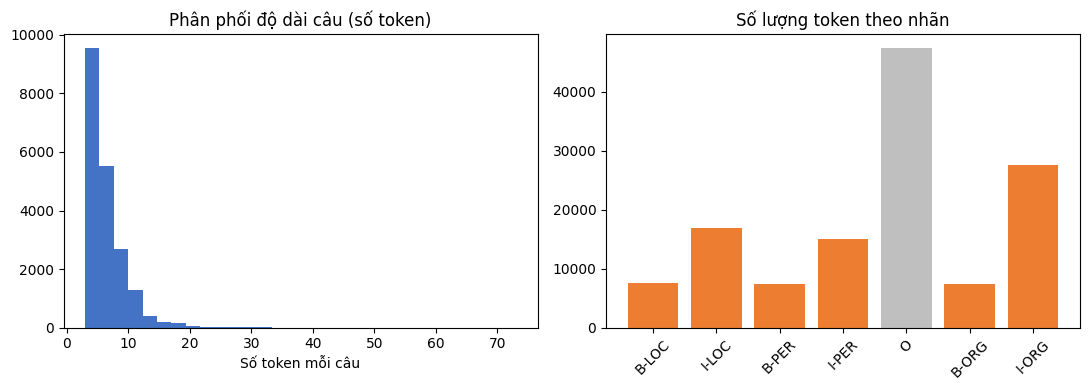

Độ dài câu: trung bình 6.5 token, dài nhất 73 token.
Tỷ lệ nhãn 'O' (không phải thực thể): 36.7% trên tổng 129,439 token.

Đọc con số này cho đúng: tỷ lệ O ở đây chỉ 36.7%, THẤP bất thường. Nguyên nhân là
WikiAnn lấy từ tiêu đề và liên kết Wikipedia nên câu rất ngắn (6.5 token) và đậm đặc
thực thể. Văn bản thật (báo chí, tin nhắn, hợp đồng) có tỷ lệ O thường trên 90%.

Hệ quả trực tiếp tới cách đánh giá: với dữ liệu thật, một model đoán O cho MỌI token vẫn đạt
Accuracy trên 90% mà hoàn toàn vô dụng. Đó là lý do bài toán lệch lớp như NER luôn phải đo
bằng Precision/Recall/F1 theo TỪNG loại thực thể (thư viện seqeval), không bao giờ dùng
Accuracy thô, bất kể tỷ lệ lớp trên tập train cụ thể là bao nhiêu.


In [4]:
import matplotlib.pyplot as plt
from collections import Counter

lengths = [len(ex["tokens"]) for ex in raw["train"]]
id2name = {i: n for i, n in enumerate(label_names)}
tag_counts_named = Counter()
for ex in raw["train"]:
    for t in ex["ner_tags"]:
        tag_counts_named[id2name[t]] += 1

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(lengths, bins=30, color="#4472C4")
axes[0].set_title("Phân phối độ dài câu (số token)")
axes[0].set_xlabel("Số token mỗi câu")

names = list(tag_counts_named.keys())
counts = [tag_counts_named[n] for n in names]
colors = ["#BFBFBF" if n == "O" else "#ED7D31" for n in names]
axes[1].bar(names, counts, color=colors)
axes[1].set_title("Số lượng token theo nhãn")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

total_tokens = sum(tag_counts_named.values())
o_ratio = tag_counts_named["O"] / total_tokens
avg_len = sum(lengths) / len(lengths)
print(f"Độ dài câu: trung bình {avg_len:.1f} token, dài nhất {max(lengths)} token.")
print(f"Tỷ lệ nhãn 'O' (không phải thực thể): {o_ratio*100:.1f}% trên tổng {total_tokens:,} token.")
print()
print(f"Đọc con số này cho đúng: tỷ lệ O ở đây chỉ {o_ratio*100:.1f}%, THẤP bất thường. Nguyên nhân là")
print(f"WikiAnn lấy từ tiêu đề và liên kết Wikipedia nên câu rất ngắn ({avg_len:.1f} token) và đậm đặc")
print("thực thể. Văn bản thật (báo chí, tin nhắn, hợp đồng) có tỷ lệ O thường trên 90%.")
print()
print("Hệ quả trực tiếp tới cách đánh giá: với dữ liệu thật, một model đoán O cho MỌI token vẫn đạt")
print("Accuracy trên 90% mà hoàn toàn vô dụng. Đó là lý do bài toán lệch lớp như NER luôn phải đo")
print("bằng Precision/Recall/F1 theo TỪNG loại thực thể (thư viện seqeval), không bao giờ dùng")
print("Accuracy thô, bất kể tỷ lệ lớp trên tập train cụ thể là bao nhiêu.")

In [5]:
# --- Phân tích sâu hơn: thực thể trông như thế nào, câu dài tới đâu ---
from collections import Counter, defaultdict

ent_examples = defaultdict(list)
ent_len = defaultdict(list)
for ex in raw["train"]:
    cur_type, cur_words = None, []
    for w, t in zip(ex["tokens"], ex["ner_tags"]):
        name = id2name[t]
        if name.startswith("B-"):
            if cur_type:
                ent_examples[cur_type].append(" ".join(cur_words)); ent_len[cur_type].append(len(cur_words))
            cur_type, cur_words = name[2:], [w]
        elif name.startswith("I-") and cur_type == name[2:]:
            cur_words.append(w)
        else:
            if cur_type:
                ent_examples[cur_type].append(" ".join(cur_words)); ent_len[cur_type].append(len(cur_words))
            cur_type, cur_words = None, []
    if cur_type:
        ent_examples[cur_type].append(" ".join(cur_words)); ent_len[cur_type].append(len(cur_words))

print("Số thực thể theo loại (tập train):")
for t in ["PER", "ORG", "LOC"]:
    n, avg = len(ent_examples[t]), sum(ent_len[t]) / max(1, len(ent_len[t]))
    top = [w for w, _ in Counter(ent_examples[t]).most_common(4)]
    print(f"  {t}: {n:>6,} thực thể | dài TB {avg:.1f} từ | hay gặp: {', '.join(top)}")

over = sum(1 for ex in raw["train"] if len(ex["tokens"]) > 128)
print(f"\nCâu dài hơn MAX_LEN=128 token: {over}/{len(raw['train'])} "
      f"({over / len(raw['train']) * 100:.2f}%) -> phần bị cắt là không đáng kể.")
print("Nếu tỷ lệ này lớn (>5%), phải tăng MAX_LEN hoặc dùng sliding window, "
      "nếu không sẽ mất thực thể nằm ở cuối câu.")

Số thực thể theo loại (tập train):
  PER:  7,470 thực thể | dài TB 3.0 từ | hay gặp: Thiên hoàng Minh Trị, Rihanna, Rafael Nadal, Lady Gaga
  ORG:  7,364 thực thể | dài TB 4.8 từ | hay gặp: Danh sách vua Triều Tiên, Thiếu tướng, Tối cao Pháp viện Hoa Kỳ, Hội đồng Khoa học Quốc tế
  LOC:  7,588 thực thể | dài TB 3.2 từ | hay gặp: Hoa Kỳ, Đức, Pháp, Thành phố Hồ Chí Minh



Câu dài hơn MAX_LEN=128 token: 0/20000 (0.00%) -> phần bị cắt là không đáng kể.
Nếu tỷ lệ này lớn (>5%), phải tăng MAX_LEN hoặc dùng sliding window, nếu không sẽ mất thực thể nằm ở cuối câu.


## 3. Tokenize + căn nhãn theo subword

PhoBERT dùng tokenizer BPE **chậm** (không phải fast/Rust tokenizer), nên KHÔNG dùng được
`tokenizer(..., is_split_into_words=True)` rồi `.word_ids()` như công thức chuẩn của HuggingFace
cho fast tokenizer. Phải tự tokenize TỪNG TỪ rồi đếm số subword để căn nhãn tay: subword đầu của
mỗi từ giữ nhãn thật, các subword sau bị đánh dấu `-100` (loss bỏ qua) -- đúng quy ước chuẩn.

In [6]:
from transformers import AutoTokenizer

MODEL_NAME = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 128


def tokenize_and_align(example):
    words = example["tokens"]
    tags = example["ner_tags"]

    input_ids = [tokenizer.bos_token_id]
    labels = [-100]
    for word, tag in zip(words, tags):
        sub_ids = tokenizer.encode(word, add_special_tokens=False)
        if not sub_ids:
            continue
        input_ids.extend(sub_ids)
        labels.append(tag)
        labels.extend([-100] * (len(sub_ids) - 1))

    input_ids = input_ids[: MAX_LEN - 1] + [tokenizer.eos_token_id]
    labels = labels[: MAX_LEN - 1] + [-100]
    attention_mask = [1] * len(input_ids)
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


sample = tokenize_and_align(raw["train"][0])
print("input_ids:", sample["input_ids"][:12])
print("labels   :", sample["labels"][:12])
assert len(sample["input_ids"]) == len(sample["labels"]) == len(sample["attention_mask"])
print("Khớp độ dài input_ids / labels / attention_mask -- căn nhãn đúng.")

input_ids: [0, 2316, 121, 490, 19464, 1871, 2]
labels   : [-100, 5, 6, 6, 6, 6, -100]
Khớp độ dài input_ids / labels / attention_mask -- căn nhãn đúng.


In [7]:
tokenized = raw.map(tokenize_and_align, remove_columns=raw["train"].column_names)
print(tokenized)

DatasetDict({
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 10000
    })
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 20000
    })
})


## 4. Train: fine-tune PhoBERT cho Token Classification

In [8]:
from transformers import AutoModelForTokenClassification, DataCollatorForTokenClassification
from transformers import TrainingArguments, Trainer
import numpy as np
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

id2label = {i: l for i, l in enumerate(label_names)}
label2id = {l: i for i, l in enumerate(label_names)}

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME, num_labels=len(label_names), id2label=id2label, label2id=label2id,
).to(DEVICE)

collator = DataCollatorForTokenClassification(tokenizer=tokenizer, label_pad_token_id=-100)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    true_preds, true_labels = [], []
    for pred_row, label_row in zip(preds, labels):
        p_seq, l_seq = [], []
        for p, l in zip(pred_row, label_row):
            if l == -100:
                continue
            p_seq.append(id2label[p])
            l_seq.append(id2label[l])
        true_preds.append(p_seq)
        true_labels.append(l_seq)
    return {
        "precision": precision_score(true_labels, true_preds),
        "recall": recall_score(true_labels, true_preds),
        "f1": f1_score(true_labels, true_preds),
    }


args = TrainingArguments(
    output_dir=str(CKPT_DIR),
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=100,
    report_to=[],
    fp16=(DEVICE == "cuda"),
    seed=0,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)

train_result = trainer.train()
print(train_result)

Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


/tmp/ipykernel_1578661/1271838583.py:51: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.267900,0.231815,0.854293,0.880172,0.867039
2,0.191500,0.193672,0.886057,0.897775,0.891877
3,0.131200,0.184274,0.894505,0.906175,0.900302


TrainOutput(global_step=1875, training_loss=0.2496670384724935, metrics={'train_runtime': 72.9346, 'train_samples_per_second': 822.655, 'train_steps_per_second': 25.708, 'total_flos': 769994692665792.0, 'train_loss': 0.2496670384724935, 'epoch': 3.0})


## 5. Đánh giá trên tập test (chưa từng thấy khi train)

In [9]:
test_metrics = trainer.evaluate(tokenized["test"])
print(test_metrics)

preds_output = trainer.predict(tokenized["test"])
logits, labels = preds_output.predictions, preds_output.label_ids
preds = np.argmax(logits, axis=-1)
true_preds, true_labels = [], []
for pred_row, label_row in zip(preds, labels):
    p_seq, l_seq = [], []
    for p, l in zip(pred_row, label_row):
        if l == -100:
            continue
        p_seq.append(id2label[p])
        l_seq.append(id2label[l])
    true_preds.append(p_seq)
    true_labels.append(l_seq)

print(classification_report(true_labels, true_preds, digits=3))

{'eval_loss': 0.18817947804927826, 'eval_precision': 0.892575731045351, 'eval_recall': 0.901813356921716, 'eval_f1': 0.8971707660491925, 'eval_runtime': 2.1043, 'eval_samples_per_second': 4752.086, 'eval_steps_per_second': 74.608, 'epoch': 3.0}


              precision    recall  f1-score   support

         LOC      0.884     0.920     0.902      3717
         ORG      0.882     0.851     0.866      3704
         PER      0.910     0.933     0.921      3884

   micro avg      0.893     0.902     0.897     11305
   macro avg      0.892     0.901     0.896     11305
weighted avg      0.892     0.902     0.897     11305



## 6. Phân tích lỗi — model sai ở đâu và vì sao?

Chỉ nhìn F1 tổng thì không biết phải cải thiện chỗ nào. Ba phân tích dưới đây trả lời:
loại thực thể nào yếu nhất, model hay nhầm loại nào với loại nào, và những câu sai trông ra sao.

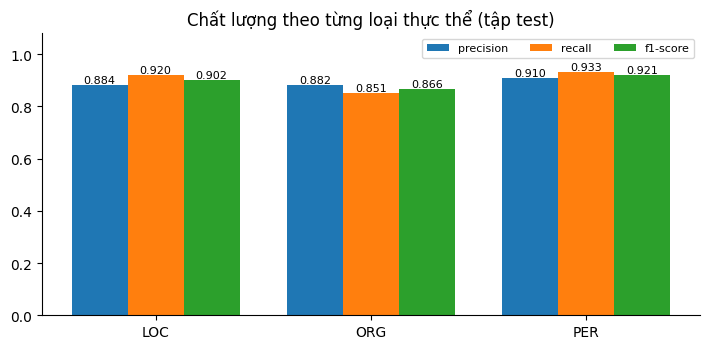

Loại yếu nhất: ORG (F1 = 0.866, support = 3704).
Recall thấp = bỏ sót thực thể; Precision thấp = gán nhãn thừa. Hai loại lỗi này cần cách sửa khác nhau.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- 6.1 F1 theo từng loại thực thể ---
from seqeval.metrics import classification_report as seq_report
rep = seq_report(true_labels, true_preds, output_dict=True, digits=3)
types = [k for k in rep if k in ("PER", "ORG", "LOC")]
metrics = ["precision", "recall", "f1-score"]

fig, ax = plt.subplots(figsize=(7.2, 3.6))
x = np.arange(len(types)); w = 0.26
for i, m in enumerate(metrics):
    vals = [rep[t][m] for t in types]
    b = ax.bar(x + (i - 1) * w, vals, w, label=m)
    ax.bar_label(b, fmt="%.3f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(types); ax.set_ylim(0, 1.08)
ax.set_title("Chất lượng theo từng loại thực thể (tập test)")
ax.legend(fontsize=8, ncol=3); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

worst = min(types, key=lambda t: rep[t]["f1-score"])
print(f"Loại yếu nhất: {worst} (F1 = {rep[worst]['f1-score']:.3f}, "
      f"support = {rep[worst]['support']}).")
print("Recall thấp = bỏ sót thực thể; Precision thấp = gán nhãn thừa. "
      "Hai loại lỗi này cần cách sửa khác nhau.")

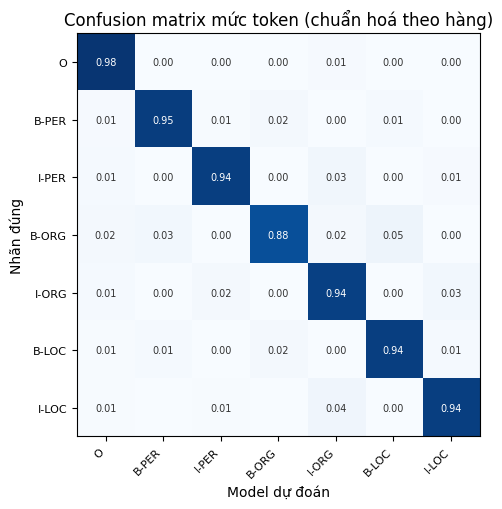

5 cặp nhầm lẫn nhiều nhất:
  đúng I-ORG  -> đoán I-LOC  :   412 token
  đúng I-LOC  -> đoán I-ORG  :   328 token
  đúng I-ORG  -> đoán I-PER  :   267 token
  đúng I-PER  -> đoán I-ORG  :   249 token
  đúng O      -> đoán I-ORG  :   198 token


In [11]:
# --- 6.2 Confusion matrix ở mức TOKEN: model nhầm loại nào với loại nào? ---
labels_flat_true = [l for seq in true_labels for l in seq]
labels_flat_pred = [l for seq in true_preds for l in seq]
uniq = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC"]
idx = {l: i for i, l in enumerate(uniq)}

cm = np.zeros((len(uniq), len(uniq)), dtype=int)
for t, p in zip(labels_flat_true, labels_flat_pred):
    cm[idx[t], idx[p]] += 1
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(uniq))); ax.set_xticklabels(uniq, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(uniq))); ax.set_yticklabels(uniq, fontsize=8)
ax.set_xlabel("Model dự đoán"); ax.set_ylabel("Nhãn đúng")
ax.set_title("Confusion matrix mức token (chuẩn hoá theo hàng)")
for i in range(len(uniq)):
    for j in range(len(uniq)):
        if cm[i, j]:
            ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if cm_norm[i, j] > 0.5 else "#333")
plt.tight_layout(); plt.show()

off = [(uniq[i], uniq[j], cm[i, j]) for i in range(len(uniq)) for j in range(len(uniq))
       if i != j and cm[i, j] > 0]
off.sort(key=lambda z: -z[2])
print("5 cặp nhầm lẫn nhiều nhất:")
for t, p, n in off[:5]:
    print(f"  đúng {t:6s} -> đoán {p:6s} : {n:5d} token")

In [12]:
# --- 6.3 Xem TẬN MẮT vài câu model đoán sai ---
shown = 0
for si, (t_seq, p_seq) in enumerate(zip(true_labels, true_preds)):
    if t_seq == p_seq or shown >= 3:
        continue
    words = raw["test"][si]["tokens"]
    if len(words) > 14:
        continue
    print(f"--- Câu test #{si} ---")
    print("  ", " ".join(words))
    for w, t, p in zip(words, t_seq, p_seq):
        if t != p:
            print(f"     {w:<18s} đúng={t:<7s} đoán={p:<7s}  <-- SAI")
    shown += 1
    print()
print("Đọc các ca sai giúp phân biệt: model yếu thật, hay do nhãn gốc trong dataset không nhất quán.")

--- Câu test #0 ---
   Hà Nội & Thành phố Hồ Chí Minh
     &                  đúng=O       đoán=I-LOC    <-- SAI
     Thành              đúng=B-LOC   đoán=I-LOC    <-- SAI

--- Câu test #6 ---
   Khủng hoảng tài chính Hoa Kỳ năm 2007
     Khủng              đúng=B-LOC   đoán=B-ORG    <-- SAI
     hoảng              đúng=I-LOC   đoán=I-ORG    <-- SAI
     tài                đúng=I-LOC   đoán=I-ORG    <-- SAI
     chính              đúng=I-LOC   đoán=I-ORG    <-- SAI
     Hoa                đúng=I-LOC   đoán=I-ORG    <-- SAI
     Kỳ                 đúng=I-LOC   đoán=I-ORG    <-- SAI
     năm                đúng=I-LOC   đoán=I-ORG    <-- SAI
     2007               đúng=I-LOC   đoán=I-ORG    <-- SAI

--- Câu test #19 ---
   Từ Cẩm Giang vai Ngao Bái
     Ngao               đúng=B-PER   đoán=O        <-- SAI
     Bái                đúng=I-PER   đoán=O        <-- SAI

Đọc các ca sai giúp phân biệt: model yếu thật, hay do nhãn gốc trong dataset không nhất quán.


In [13]:
import re

# Cách tách từ này phải GIỐNG HỆT phía phục vụ (services/api/app/core/tokenization.py).
# Dùng chung một quy ước là điều kiện bắt buộc để model cho cùng kết quả ở hai nơi.
WORD_RE = re.compile(r"\d+(?:[.,:/]\d+)+|\w+|([^\w\s])\1*", re.UNICODE)


def split_words(text):
    """Tách văn bản thành từ, TÁCH RIÊNG dấu câu, kèm vị trí ký tự.

    Dấu câu phải là token riêng vì dữ liệu huấn luyện (WikiAnn) được tách như vậy.
    Mục 8 ngay dưới đây đo cụ thể chuyện gì xảy ra nếu làm khác đi.
    """
    return [(m.group(0), m.start(), m.end()) for m in WORD_RE.finditer(text)]


def predict_sentence(text, words=None):
    """Dự đoán nhãn BIO cho từng từ trong câu.

    Tham số `words` cho phép truyền vào cách tách từ khác, dùng ở mục 8 để so
    hai cách tách với nhau.
    """
    if words is None:
        words = [w for w, _s, _e in split_words(text)]

    enc = tokenize_and_align({"tokens": words, "ner_tags": [0] * len(words)})
    input_ids = torch.tensor([enc["input_ids"]]).to(DEVICE)
    attention_mask = torch.tensor([enc["attention_mask"]]).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
    pred_ids = logits.argmax(-1)[0].tolist()

    # Nhãn của một từ nằm ở SUBWORD ĐẦU TIÊN của nó, đúng như lúc căn nhãn khi train.
    results, idx = [], 1          # bỏ qua token mở đầu câu ở vị trí 0
    for word in words:
        sub_ids = tokenizer.encode(word, add_special_tokens=False)
        if not sub_ids or idx >= len(pred_ids):
            continue
        results.append((word, id2label[pred_ids[idx]]))
        idx += len(sub_ids)
    return results


for sentence in ["Nguyễn Bá Thiêm làm việc tại Google ở Hà Nội.",
                 "Việt Nam và Hoa Kỳ hợp tác về công nghệ AI."]:
    print(sentence)
    print("   ", " | ".join(f"{w}:{l}" for w, l in predict_sentence(sentence) if l != "O"))
    print()

Nguyễn Bá Thiêm làm việc tại Google ở Hà Nội.
    Nguyễn:B-PER | Bá:I-PER | Thiêm:I-PER | Google:B-ORG | Hà:B-LOC | Nội:I-LOC

Việt Nam và Hoa Kỳ hợp tác về công nghệ AI.
    Việt:B-LOC | Nam:I-LOC | Hoa:B-LOC | Kỳ:I-LOC | AI:B-ORG



## 7. Thử các tình huống thực tế

Model vừa đạt F1 cao trên tập test, nhưng tập test đó **cùng phân phối** với tập train. Dữ liệu
ngoài đời thì không. Bốn nhóm câu dưới đây mô phỏng những gì thực sự hay gặp, và cho thấy giới hạn
thật của model trước khi đem đi phục vụ.

In [14]:
SCENARIOS = [
    ("Giống dữ liệu huấn luyện", "Nguyễn Bá Thiêm làm việc tại Google ở Hà Nội ."),
    ("Tên tổ chức lạ",           "Công ty VinFast hợp tác với Đại học Bách Khoa ."),
    ("Viết thường hết",          "nguyễn văn a sống ở đà nẵng ."),
    ("Có tiếng Anh xen kẽ",      "CEO Tim Cook của Apple đến thăm TP Hồ Chí Minh ."),
]

for title, sentence in SCENARIOS:
    print(f"--- {title} ---")
    print("  ", sentence)
    found = [f"{w}:{l}" for w, l in predict_sentence(sentence) if l != "O"]
    print("   ", " | ".join(found) if found else "(không tìm thấy thực thể nào)")
    print()

print("Quan sát: chữ viết thường làm model yếu hẳn, vì WikiAnn hầu như viết hoa đúng chuẩn.")
print("Đây chính là Data Drift: dữ liệu thật (bình luận, tin nhắn) hay viết thường và sai chính tả,")
print("khác hẳn dữ liệu huấn luyện.")
print("Hai hướng xử lý: bổ sung dữ liệu viết thường vào tập train, hoặc chuẩn hoá hoa/thường ở bước")
print("tiền xử lý. Cách nào cũng phải đo lại, đừng chọn theo cảm tính.")

--- Giống dữ liệu huấn luyện ---
   Nguyễn Bá Thiêm làm việc tại Google ở Hà Nội .
    Nguyễn:B-PER | Bá:I-PER | Thiêm:I-PER | Google:B-ORG | Hà:B-LOC | Nội:I-LOC

--- Tên tổ chức lạ ---
   Công ty VinFast hợp tác với Đại học Bách Khoa .
    VinFast:B-ORG | Đại:B-ORG | học:I-ORG | Bách:I-ORG | Khoa:I-ORG

--- Viết thường hết ---
   nguyễn văn a sống ở đà nẵng .
    đà:B-LOC | nẵng:I-LOC

--- Có tiếng Anh xen kẽ ---
   CEO Tim Cook của Apple đến thăm TP Hồ Chí Minh .
    Tim:B-PER | Cook:I-PER | Apple:B-ORG | Hồ:B-LOC | Chí:I-LOC | Minh:I-LOC

Quan sát: chữ viết thường làm model yếu hẳn, vì WikiAnn hầu như viết hoa đúng chuẩn.
Đây chính là Data Drift: dữ liệu thật (bình luận, tin nhắn) hay viết thường và sai chính tả,
khác hẳn dữ liệu huấn luyện.
Hai hướng xử lý: bổ sung dữ liệu viết thường vào tập train, hoặc chuẩn hoá hoa/thường ở bước
tiền xử lý. Cách nào cũng phải đo lại, đừng chọn theo cảm tính.


## 8. Bài học: lệch tiền xử lý giữa lúc huấn luyện và lúc phục vụ

Đây là lỗi tốn thời gian nhất trong cả dự án này, và nó **không hề làm chương trình báo lỗi**.
Model vẫn chạy, API vẫn trả 200, chỉ có kết quả là sai một cách âm thầm.

Dữ liệu WikiAnn tách dấu câu thành **token riêng**:

```
['anh', 'Nguyễn', 'Viết', 'Quang', ',', '40', 'tuổi']
```

Nhưng cách tách đơn giản nhất khi phục vụ, `text.split()`, lại cho ra:

```
['anh', 'Nguyễn', 'Viết', 'Quang,', '40', 'tuổi']
```

Token `Quang,` chưa từng xuất hiện lúc huấn luyện. Ô dưới đây đo xem điều đó gây ra hậu quả gì.

In [15]:
SKEW_TEXT = ("Sau ca phẫu thuật, anh Nguyễn Viết Quang, 40 tuổi, sống sót tại xã Bình Minh. "
             "Vợ anh là chị Hồ Thị Mai, 36 tuổi. Không có mâu thuẫn với Nguyễn Đức Anh, 21 tuổi.")

naive = SKEW_TEXT.split()                              # cách sai: dấu câu dính vào từ
correct = [w for w, _s, _e in split_words(SKEW_TEXT)]  # cách đúng: dấu câu tách riêng


def tagged(words):
    """Trả về danh sách (từ đã bỏ dấu câu bám ngoài, nhãn) cho các từ được gán thực thể."""
    return [(w.strip(",.;:\"'"), l) for w, l in predict_sentence(SKEW_TEXT, words=words) if l != "O"]


a, b = tagged(naive), tagged(correct)
print(f"A. text.split()          {len(naive):3d} token -> {len(a):2d} từ được gán thực thể")
print("  ", " | ".join(f"{w}:{l}" for w, l in a))
print()
print(f"B. tách riêng dấu câu    {len(correct):3d} token -> {len(b):2d} từ được gán thực thể")
print("  ", " | ".join(f"{w}:{l}" for w, l in b))
print()

missing = [w for w, _l in b if w not in {x for x, _ in a}]
print(f"Cách A bỏ sót {len(missing)} từ mà cách B nhận ra: {missing}")
print()

# Chỉ ra vị trí của các từ bị sót so với dấu câu, để kết luận rút ra từ dữ liệu chứ không phải phỏng đoán.
for w in missing:
    i = SKEW_TEXT.find(w)
    after = SKEW_TEXT[i + len(w):i + len(w) + 1]
    print(f"   {w!r:12s} ký tự ngay sau nó trong câu: {after!r}")
print()
print("Quy luật lộ ra: mỗi khi một từ bị dính dấu câu, token đó trở thành chuỗi chưa từng xuất hiện")
print("lúc huấn luyện, và thực thể bị ĐỨT ngay tại đó. Từ đứng trước dấu câu và các từ còn lại của")
print("cùng thực thể đều mất nhãn theo. Model không hề yếu, khâu tiền xử lý mới sai.")
print("Hiện tượng này gọi là training/serving skew: lệch giữa cách xử lý dữ liệu lúc huấn luyện và")
print("lúc phục vụ.")
print()
print("Ba điều rút ra, áp dụng được cho mọi dự án:")
print("  1. Mọi bước tiền xử lý phải dùng CHUNG một hàm cho cả huấn luyện lẫn phục vụ.")
print("     Trong repo này là services/api/app/core/tokenization.py; ô phía trên chép đúng quy ước đó.")
print("  2. Lỗi loại này không bao giờ tự lộ ra: không có exception, không có log đỏ, HTTP vẫn 200.")
print("     Chỉ test hồi quy mới bắt được. tests/test_pipeline.py có một ca canh riêng cho nó.")
print("  3. Trước khi kết luận model kém, hãy kiểm tra đầu vào lúc phục vụ có giống đầu vào lúc")
print("     huấn luyện hay không.")

A. text.split()           35 token ->  7 từ được gán thực thể
   Nguyễn:B-PER | Bình:B-LOC | Minh:I-LOC | Hồ:B-PER | Nguyễn:B-PER | Đức:I-PER | Anh:I-PER

B. tách riêng dấu câu     43 token -> 11 từ được gán thực thể
   Nguyễn:B-PER | Viết:I-PER | Quang:I-PER | Bình:B-LOC | Minh:I-LOC | Hồ:B-PER | Thị:I-PER | Mai:I-PER | Nguyễn:B-PER | Đức:I-PER | Anh:I-PER

Cách A bỏ sót 4 từ mà cách B nhận ra: ['Viết', 'Quang', 'Thị', 'Mai']

   'Viết'       ký tự ngay sau nó trong câu: ' '
   'Quang'      ký tự ngay sau nó trong câu: ','
   'Thị'        ký tự ngay sau nó trong câu: ' '
   'Mai'        ký tự ngay sau nó trong câu: ','

Quy luật lộ ra: mỗi khi một từ bị dính dấu câu, token đó trở thành chuỗi chưa từng xuất hiện
lúc huấn luyện, và thực thể bị ĐỨT ngay tại đó. Từ đứng trước dấu câu và các từ còn lại của
cùng thực thể đều mất nhãn theo. Model không hề yếu, khâu tiền xử lý mới sai.
Hiện tượng này gọi là training/serving skew: lệch giữa cách xử lý dữ liệu lúc huấn luyện và
lúc phục vụ.

Ba

## 9. Xuất ONNX và kiểm chứng lại

ONNX là định dạng trung gian: xuất một lần rồi chạy được trên nhiều runtime khác nhau (ONNX Runtime,
TensorRT, OpenVINO) mà không cần PyTorch trong môi trường phục vụ. Nhờ vậy image phục vụ nhẹ đi rất
nhiều và không phụ thuộc vào phiên bản PyTorch.

Đừng chỉ tin là xuất đúng. Ô kiểm chứng bên dưới so trực tiếp logits của ONNX với logits của PyTorch
trên cùng một đầu vào: lệch quá ngưỡng thì dừng ngay tại đây, đừng để phát hiện ra lúc đã chạy thật.

In [16]:
import os

model.eval().to("cpu")
dummy_ids = torch.randint(0, tokenizer.vocab_size, (1, 16), dtype=torch.long)
dummy_mask = torch.ones(1, 16, dtype=torch.long)

# Xuất THẲNG vào kho model, không qua file tạm ở gốc repo. Trọng số là artifact
# 538 MB; để nó nằm lang thang thì sớm muộn cũng có người commit nhầm hoặc quên xoá.
torch.onnx.export(
    model,
    (dummy_ids, dummy_mask),
    str(ONNX_PATH),
    input_names=["input_ids", "attention_mask"],
    output_names=["logits"],
    dynamic_axes={
        "input_ids": {0: "batch", 1: "seq"},
        "attention_mask": {0: "batch", 1: "seq"},
        "logits": {0: "batch", 1: "seq"},
    },
    opset_version=14,
)
print(f"Đã xuất: {ONNX_PATH} ({os.path.getsize(ONNX_PATH) / 1e6:.1f} MB)")

<python>/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  inverted_mask = torch.tensor(1.0, dtype=dtype) - expanded_mask

Đã xuất: services/triton/model_repository/ner_onnx/1/model.onnx (538.0 MB)

In [17]:
import onnxruntime as ort

sess = ort.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])

with torch.no_grad():
    torch_logits = model(input_ids=dummy_ids, attention_mask=dummy_mask).logits.numpy()

onnx_logits = sess.run(["logits"], {
    "input_ids": dummy_ids.numpy(),
    "attention_mask": dummy_mask.numpy(),
})[0]

max_diff = abs(torch_logits - onnx_logits).max()
print(f"Sai số lớn nhất giữa PyTorch và ONNX: {max_diff:.2e}")
assert max_diff < 1e-3, "ONNX export lệch quá nhiều so với PyTorch gốc!"
print("KHỚP -- ONNX export đúng, an toàn để đưa vào serving.")

Sai số lớn nhất giữa PyTorch và ONNX: 2.05e-05
KHỚP -- ONNX export đúng, an toàn để đưa vào serving.


## 10. Kho model

Trọng số được xuất **thẳng vào kho model của Triton** ở mục 9, không đi qua file tạm nào. Cấu trúc
thư mục chính là cách đánh phiên bản:

```
services/triton/model_repository/ner_onnx/
├── config.pbtxt          cách Triton nạp và chạy model
├── labels.json           bảng nhãn
├── model_card.json       train bằng dữ liệu gì, seed nào, đạt F1 bao nhiêu
└── 1/model.onnx          trọng số, phiên bản 1
```

Huấn luyện lại và muốn giữ bản cũ thì chỉ cần tạo thư mục `2/`: Triton nạp được cả hai cùng lúc, và
chuyển dần lưu lượng sang bản mới mà không phải dừng dịch vụ.

`model_card.json` là phần hay bị bỏ quên nhất. Trọng số không tự nói được nó đến từ đâu; không có
file này thì ba tháng sau không ai biết model đang chạy được train bằng dữ liệu gì và đạt bao nhiêu.

Tokenizer nằm ở lớp ứng dụng (`services/api/`) chứ không nằm trong Triton: Triton chỉ nhận tensor và
trả tensor, nó không biết gì về chữ nghĩa.

In [18]:
import json, os, shutil
from datetime import date

# --- 1. Bản CPU: liên kết tượng trưng, không nhân đôi 538 MB trên đĩa ---
(TRITON_CPU_DIR / str(MODEL_VERSION)).mkdir(parents=True, exist_ok=True)
cpu_weight = TRITON_CPU_DIR / str(MODEL_VERSION) / "model.onnx"
if cpu_weight.exists() or cpu_weight.is_symlink():
    cpu_weight.unlink()
try:
    cpu_weight.symlink_to(Path(f"../../ner_onnx/{MODEL_VERSION}/model.onnx"))
    link_note = "liên kết tượng trưng"
except OSError:
    # Windows không cho tạo symlink nếu chưa bật Developer Mode. Chép hẳn vẫn đúng.
    shutil.copy(ONNX_PATH, cpu_weight)
    link_note = "bản sao (hệ điều hành không cho tạo liên kết tượng trưng)"

# --- 2. Bảng nhãn và tokenizer ---
API_DIR.mkdir(parents=True, exist_ok=True)
for target in (TRITON_GPU_DIR / "labels.json", API_DIR / "labels.json"):
    with open(target, "w", encoding="utf-8") as f:
        json.dump(id2label, f, ensure_ascii=False, indent=2)
tokenizer.save_pretrained(API_DIR / "tokenizer")

# --- 3. Model card: model này train ra sao, đạt bao nhiêu ---
# Trọng số không tự nói được nó đến từ đâu. Không có file này thì ba tháng sau
# không ai biết model đang chạy được train bằng dữ liệu gì, đạt F1 bao nhiêu, và
# có so được với bản mới hay không.
card = {
    "name": "phobert-ner",
    "version": MODEL_VERSION,
    "created": date.today().isoformat(),
    "base_model": MODEL_NAME,
    "task": "token-classification (NER: PER, ORG, LOC)",
    "dataset": "wikiann/vi",
    "train_size": len(raw["train"]),
    "test_size": len(raw["test"]),
    "max_len": MAX_LEN,
    "epochs": args.num_train_epochs,
    "learning_rate": args.learning_rate,
    "seed": args.seed,
    "test_metrics": {k: round(float(v), 4) for k, v in test_metrics.items()
                     if isinstance(v, (int, float)) and k.startswith("eval_")},
    "labels": list(id2label.values()),
    "tokenization": "tách dấu câu thành token riêng, xem services/api/app/core/tokenization.py",
}
with open(TRITON_GPU_DIR / "model_card.json", "w", encoding="utf-8") as f:
    json.dump(card, f, ensure_ascii=False, indent=2)

size_mb = os.path.getsize(ONNX_PATH) / 1e6
print("Kho model sau khi ghi (đường dẫn tính từ gốc repo):")
print(f"  {_rel(TRITON_GPU_DIR)}/")
print(f"    config.pbtxt        cách Triton nạp và chạy")
print(f"    labels.json         bảng nhãn")
print(f"    model_card.json     F1 = {card['test_metrics'].get('eval_f1')}, seed = {card['seed']}")
print(f"    {MODEL_VERSION}/model.onnx       {size_mb:.1f} MB")
print(f"  {_rel(TRITON_CPU_DIR)}/{MODEL_VERSION}/model.onnx   ({link_note})")
print(f"  {_rel(API_DIR)}/tokenizer/, labels.json")

assert ONNX_PATH.exists() and (API_DIR / "tokenizer" / "vocab.txt").exists()
print("\nĐã kiểm tra: mọi artifact đều tồn tại.")

# --- 4. Trên Colab thì nén lại để tải về ---
if MODE == "standalone":
    archive = shutil.make_archive(str(Path.cwd() / "nlp-ops-artifacts"), "zip",
                                  root_dir=str(ARTIFACT_ROOT))
    print(f"\nĐã đóng gói: {archive} ({os.path.getsize(archive)/1e6:.0f} MB)")
    print("Tải về rồi giải nén ĐÈ LÊN thư mục gốc repo trên máy bạn:")
    print("    unzip -o nlp-ops-artifacts.zip -d /duong/dan/toi/nlp-ops-basic")
    if IN_COLAB:
        from google.colab import files
        files.download(archive)

Kho model sau khi ghi:
  services/triton/model_repository/ner_onnx/
    config.pbtxt        cách Triton nạp và chạy
    labels.json         bảng nhãn
    model_card.json     F1 = 0.8972, seed = 0
    1/model.onnx       538.0 MB
  services/triton/model_repository/ner_onnx_cpu/1/model.onnx   (liên kết tượng trưng)
  services/api/tokenizer/, labels.json

Đã kiểm tra: mọi artifact đều tồn tại.

## Bước tiếp theo

Artifact đã sẵn sàng. Quay về thư mục gốc của repo và dựng hệ thống:

```bash
docker compose up -d              # Triton + FastAPI + Prometheus + Grafana
python3 tests/test_pipeline.py    # kiểm thử end-to-end
```

Sau đó:

| Việc | Lệnh hoặc địa chỉ |
|---|---|
| Thử trên giao diện web | http://localhost:8080 |
| Đọc tài liệu API tự sinh | http://localhost:8080/docs |
| Chấm điểm chất lượng và tốc độ | `python3 benchmarks/run_benchmark.py` |
| Đo tải, tìm điểm bão hoà | `bash load_test/run_stress_test.sh` |
| Xem bảng giám sát vận hành | http://localhost:3001 |

Gặp lỗi thì tra `docs/TROUBLESHOOTING.md` trước khi tìm trên mạng: phần lớn lỗi hay gặp của hệ thống
này đã được ghi lại ở đó kèm cách chẩn đoán.